<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/ncs_wind_battery_gas_electrification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wind, battery, and gas-turbine power for Norwegian offshore processes

This notebook connects a NeqSim oil-and-gas process load to chronological offshore
wind, gas-turbine balancing, and battery storage. It compares direct offshore CO₂
emissions, wind utilisation, gas-turbine duty and ramps, curtailment, storage
throughput, and firm-capacity needs.

The study is an open, reproducible screening example. It is not a design basis,
power-system study, vendor guarantee, or prediction for Snorre or Gullfaks.

## Learning objectives and decision questions

After running the notebook, you can:

1. build NeqSim directly from a pinned commit in the
   [`equinor/neqsim`](https://github.com/equinor/neqsim) repository;
2. calculate an export-compressor load with an SRK process model;
3. reproduce NeqSim's native offshore wind–gas time-series benchmark;
4. connect process demand, wind, gas generation, and storage through typed
   `EnergyPort` and `EnergyBus` objects;
5. run `EnergyTimeSeriesProfile` and `EnergyTimeSeriesSimulator` chronologically;
6. quantify when a battery captures curtailed wind and when it cannot reduce CO₂;
7. screen gas-turbine reserve and ramping needs; and
8. distinguish direct offshore emissions from wider lifecycle or grid impacts.

The central engineering questions are:

- How much gas generation and direct CO₂ can wind displace?
- Must gas turbines remain installed for low-wind periods?
- Does a battery materially improve CO₂ reduction, or mainly improve operability?
- How do the answers change as a field matures and electrical demand falls?

## Public reference case and model boundaries

[Equinor's Hywind Tampen page](https://www.equinor.com/energy/hywind-tampen)
reports 11 turbines of 8.6 MW, a total system capacity of 94.6 MW, and an estimated
contribution of about 35% of the annual electricity demand of the five Snorre and
Gullfaks platforms. The wind farm is about 140 km offshore, in 260–300 m water
depth, and reached full operation in summer 2023.

Those public values anchor the installed wind capacity and annual-energy target.
The hourly wind trace below is **synthetic**, deterministic, and clearly labelled.
No measured Hywind Tampen production or platform operating data are used.

NeqSim's
[energy time-series documentation](https://equinor.github.io/neqsim/process/energy_time_series.html)
supplies the chronological runner and integrated KPIs. Its
[energy-stream documentation](https://equinor.github.io/neqsim/process/energy_streams.html)
supplies typed ports, the multi-party energy bus, allocation, cost and emission
metadata, and battery connections.

The direct gas-generation factor of 450 kg CO₂/MWh and the illustrative variable
cost of 90 units/MWh are taken from NeqSim's deterministic offshore reference
benchmark. They are transparent benchmark assumptions, not field measurements or
commercial forecasts.

## 1. Build the exact NeqSim source revision

The new energy-network APIs are newer than the packaged Python release. This setup
therefore fetches a pinned commit from the NeqSim repository, builds the Java
project, and starts JPype with the freshly compiled classes ahead of the shaded
dependency JAR. A clean Colab CPU runtime with Java 17 or newer is recommended.

The first run can take several minutes because Maven dependencies and the NeqSim
source must be downloaded. Later cells do not install or substitute another NeqSim
binary.

In [1]:
import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path

NEQSIM_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_COMMIT = "77f4b5b1d225372947a69864b47940fe0f86430a"
NEQSIM_ROOT = Path("/tmp") / f"neqsim-source-{NEQSIM_COMMIT[:12]}"

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "jpype1==1.7.1",
    ]
)

if not (NEQSIM_ROOT / ".git").exists():
    shutil.rmtree(NEQSIM_ROOT, ignore_errors=True)
    subprocess.check_call(
        [
            "git",
            "init",
            "--quiet",
            "--initial-branch",
            "ncs-build",
            str(NEQSIM_ROOT),
        ]
    )
    subprocess.check_call(
        [
            "git",
            "-C",
            str(NEQSIM_ROOT),
            "remote",
            "add",
            "origin",
            NEQSIM_REPOSITORY,
        ]
    )
    subprocess.check_call(
        [
            "git",
            "-C",
            str(NEQSIM_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_COMMIT,
        ]
    )
    subprocess.check_call(
        [
            "git",
            "-C",
            str(NEQSIM_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ]
    )

resolved_commit = subprocess.check_output(
    ["git", "-C", str(NEQSIM_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()
assert resolved_commit == NEQSIM_COMMIT

target_classes = NEQSIM_ROOT / "target" / "classes"
if not target_classes.exists():
    build_command = [
        str(NEQSIM_ROOT / "mvnw"),
        "--quiet",
        "-Dmaven.test.skip=true",
        "-Dmaven.wagon.http.retryHandler.count=5",
        "package",
    ]
    build_log = NEQSIM_ROOT / "colab-maven-build.log"
    for attempt in range(1, 4):
        completed = subprocess.run(
            build_command,
            cwd=NEQSIM_ROOT,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
        )
        build_log.write_text(completed.stdout, encoding="utf-8")
        if completed.returncode == 0:
            break
        if attempt == 3:
            print("\n".join(completed.stdout.splitlines()[-120:]))
            completed.check_returncode()

import jpype

jar_candidates = [
    path
    for path in (NEQSIM_ROOT / "target").glob("neqsim-*.jar")
    if not path.name.startswith("original-")
    and "-sources" not in path.name
    and "-javadoc" not in path.name
]
assert jar_candidates, "The NeqSim shaded JAR was not built."
neqsim_jar = max(jar_candidates, key=lambda path: path.stat().st_size)

if not jpype.isJVMStarted():
    jpype.startJVM(
        classpath=[
            str(target_classes),
            str(NEQSIM_ROOT / "src" / "main" / "resources"),
            str(neqsim_jar),
        ]
    )

JClass = jpype.JClass
java_system = JClass("java.lang.System")
print(f"NeqSim repository commit: {resolved_commit}")
print(f"NeqSim JAR: {neqsim_jar.name}")
print(f"Python: {platform.python_version()}")
print(f"Java: {java_system.getProperty('java.version')}")

NeqSim repository commit: 77f4b5b1d225372947a69864b47940fe0f86430a
NeqSim JAR: neqsim-3.16.0.jar
Python: 3.12.13
Java: 21.0.11


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from jpype import JArray, JDouble, JProxy

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

EnergyBus = JClass("neqsim.process.equipment.stream.EnergyBus")
EnergyPort = JClass("neqsim.process.equipment.stream.EnergyPort")
EnergyPortDirection = JClass(
    "neqsim.process.equipment.stream.EnergyPortDirection"
)
EnergyPortMode = JClass("neqsim.process.equipment.stream.EnergyPortMode")
EnergyType = JClass("neqsim.process.equipment.stream.EnergyType")
EnergyTimeSeriesProfile = JClass(
    "neqsim.process.equipment.energy.EnergyTimeSeriesProfile"
)
EnergyTimeSeriesSimulator = JClass(
    "neqsim.process.equipment.energy.EnergyTimeSeriesSimulator"
)
ProfileTarget = JClass(
    "neqsim.process.equipment.energy."
    "EnergyTimeSeriesSimulator$ProfileTarget"
)
OffshoreEnergyReferenceCase = JClass(
    "neqsim.process.equipment.energy.OffshoreEnergyReferenceCase"
)
BatteryStorage = JClass(
    "neqsim.process.equipment.battery.BatteryStorage"
)
UUID = JClass("java.util.UUID")

plt.style.use("seaborn-v0_8-whitegrid")
COLOR_WIND = "#56B4E9"
COLOR_GAS = "#D55E00"
COLOR_BATTERY = "#009E73"
COLOR_LOAD = "#222222"

In [3]:
public_inputs = pd.DataFrame(
    [
        {
            "Input": "Hywind Tampen system capacity",
            "Value": 94.6,
            "Unit": "MW",
            "Status": "Public project fact",
        },
        {
            "Input": "Wind turbines",
            "Value": 11,
            "Unit": "count",
            "Status": "Public project fact",
        },
        {
            "Input": "Rated power per turbine",
            "Value": 8.6,
            "Unit": "MW",
            "Status": "Public project fact",
        },
        {
            "Input": "Estimated annual electricity contribution",
            "Value": 35.0,
            "Unit": "%",
            "Status": "Public project estimate",
        },
        {
            "Input": "Gas-generation CO₂ factor",
            "Value": 450.0,
            "Unit": "kg CO₂/MWh",
            "Status": "NeqSim benchmark assumption",
        },
        {
            "Input": "Gas-generation variable cost",
            "Value": 90.0,
            "Unit": "benchmark units/MWh",
            "Status": "NeqSim benchmark assumption",
        },
    ]
)
display(public_inputs)

,Input,Value,Unit,Status
0,Hywind Tampen system capacity,94.6,MW,Public project fact
1,Wind turbines,11.0,count,Public project fact
2,Rated power per turbine,8.6,MW,Public project fact
3,Estimated annual electricity contribution,35.0,%,Public project estimate
4,Gas-generation CO₂ factor,450.0,kg CO₂/MWh,NeqSim benchmark assumption
5,Gas-generation variable cost,90.0,benchmark units/MWh,NeqSim benchmark assumption


## 2. Reproduce NeqSim's offshore energy benchmark

The repository contains a fixed six-interval benchmark with wind first in the
dispatch order, gas turbines second, and critical and flexible process loads. It
provides an independent acceptance target before the larger NCS screening study is
constructed.

In [4]:
benchmark_result = OffshoreEnergyReferenceCase.run24HourCase()
OffshoreEnergyReferenceCase.requireAcceptanceCriteria(benchmark_result)

benchmark_kpis = pd.Series(
    {
        "Duration [h]": (
            benchmark_result.getTotalDurationSeconds() / 3600.0
        ),
        "Served energy [MWh]": (
            benchmark_result.getServedEnergyMWh()
        ),
        "Unmet energy [MWh]": (
            benchmark_result.getUnmetEnergyMWh()
        ),
        "Total curtailed offered supply [MWh]": (
            benchmark_result.getCurtailedEnergyMWh()
        ),
        "Accepted wind [MWh]": (
            OffshoreEnergyReferenceCase.getWindGeneratedEnergyMWh(
                benchmark_result
            )
        ),
        "Accepted gas [MWh]": (
            OffshoreEnergyReferenceCase.getGasGeneratedEnergyMWh(
                benchmark_result
            )
        ),
        "Curtailed wind [MWh]": (
            OffshoreEnergyReferenceCase.getWindCurtailedEnergyMWh(
                benchmark_result
            )
        ),
        "CO₂ [kg]": benchmark_result.getCo2EmissionsKg(),
    }
)
display(benchmark_kpis.to_frame("NeqSim result"))

,NeqSim result
Duration [h],24.0
Served energy [MWh],312.0
Unmet energy [MWh],0.0
Total curtailed offered supply [MWh],196.0
Accepted wind [MWh],144.0
Accepted gas [MWh],168.0
Curtailed wind [MWh],4.0
CO₂ [kg],75600.0


The published acceptance values are 312 MWh served, zero unmet energy, 144 MWh
accepted wind, 168 MWh accepted gas, 4 MWh curtailed wind, and 75,600 kg CO₂.
Passing this gate checks profile breakpoints, allocation priority, integration, and
emission accounting in the exact source revision used by the notebook.

## 3. Derive the process load with NeqSim

A synthetic export-gas stream is compressed from 55 to 120 bara with 78% isentropic
efficiency. The cluster electrical load is separated into a thermodynamically
calculated compression term and an explicit fixed-load term:

$$
P_\mathrm{cluster}(t)
=
P_\mathrm{compressor}\!\left(\dot{m}(t)\right)
+
P_\mathrm{fixed}(t)
$$

The fixed term represents water injection, separation, cooling, pumps, utilities,
drilling or accommodation loads that are outside this compact process flowsheet.
The gas composition is normalized on a molar basis and all pressures are absolute.

In [5]:
gas_composition = {
    "methane": 0.880,
    "ethane": 0.060,
    "propane": 0.025,
    "i-butane": 0.005,
    "n-butane": 0.008,
    "CO2": 0.015,
    "nitrogen": 0.007,
}
assert math.isclose(sum(gas_composition.values()), 1.0, abs_tol=1.0e-12)


def simulate_export_compressor(flow_kg_h):
    fluid = SystemSrkEos(25.0 + 273.15, 55.0)
    for component_name, mole_fraction in gas_composition.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(float(flow_kg_h), "kg/hr")

    feed = Stream("export compressor feed", fluid)
    compressor = Compressor("export compressor", feed)
    compressor.setOutletPressure(120.0, "bara")
    compressor.setIsentropicEfficiency(0.78)

    process = ProcessSystem("export compression process")
    process.add(feed)
    process.add(compressor)
    process.run()

    outlet = compressor.getOutletStream()
    mass_flow_kg_s = feed.getFlowRate("kg/sec")
    enthalpy_change_w = mass_flow_kg_s * (
        outlet.getFluid().getEnthalpy("J/kg")
        - feed.getFluid().getEnthalpy("J/kg")
    )
    power_w = compressor.getPower("W")
    return {
        "Flow [kg/h]": flow_kg_h,
        "Power [MW]": power_w / 1.0e6,
        "Outlet temperature [°C]": outlet.getTemperature("C"),
        "Mass residual [kg/h]": (
            feed.getFlowRate("kg/hr")
            - outlet.getFlowRate("kg/hr")
        ),
        "Energy residual [W]": power_w - enthalpy_change_w,
    }


flow_grid_kg_h = np.linspace(400_000.0, 1_000_000.0, 7)
compressor_cases = pd.DataFrame(
    [
        simulate_export_compressor(flow_kg_h)
        for flow_kg_h in flow_grid_kg_h
    ]
)
display(compressor_cases.round(6))

,Flow [kg/h],Power [MW],Outlet temperature [°C],Mass residual [kg/h],Energy residual [W]
0,400000.0,14.512537,94.720231,0.0,0.0
1,500000.0,18.140672,94.720231,0.0,0.0
2,600000.0,21.768806,94.720231,0.0,0.0
3,700000.0,25.396940,94.720231,0.0,-0.0
4,800000.0,29.025075,94.720231,0.0,-0.0
5,900000.0,32.653209,94.720231,0.0,0.0
6,1000000.0,36.281343,94.720231,0.0,0.0


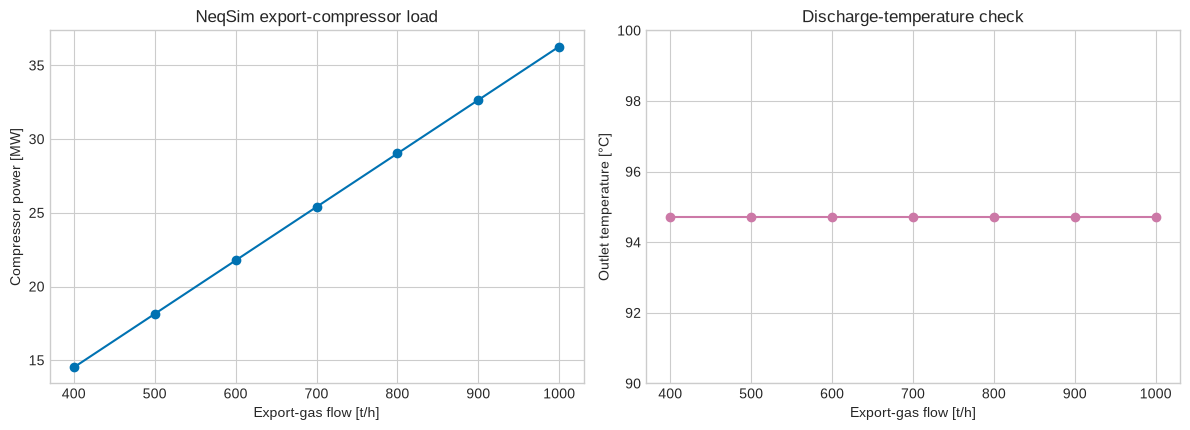

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))

axes[0].plot(
    compressor_cases["Flow [kg/h]"] / 1000.0,
    compressor_cases["Power [MW]"],
    marker="o",
    color="#0072B2",
)
axes[0].set_xlabel("Export-gas flow [t/h]")
axes[0].set_ylabel("Compressor power [MW]")
axes[0].set_title("NeqSim export-compressor load")

axes[1].plot(
    compressor_cases["Flow [kg/h]"] / 1000.0,
    compressor_cases["Outlet temperature [°C]"],
    marker="o",
    color="#CC79A7",
)
axes[1].set_xlabel("Export-gas flow [t/h]")
axes[1].set_ylabel("Outlet temperature [°C]")
axes[1].set_title("Discharge-temperature check")
axes[1].ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False,
)
axes[1].set_ylim(90.0, 100.0)

plt.tight_layout()
plt.show()

Compressor power increases smoothly with mass flow and the outlet remains hotter than
the inlet, as expected for adiabatic compression. The near-zero material and energy
residuals are retained for later validation.

## 4. Construct a transparent 30-day wind and process profile

The reference cluster is calibrated so the mean synthetic Hywind-scale production is
35% of mean cluster demand:

$$
\overline{P}_\mathrm{cluster}
=
\frac{\overline{P}_\mathrm{wind}}{0.35}
$$

A second, hypothetical **compact mature-field hub** uses 55% of that demand. It is
not a model of a named asset; it tests a common late-life situation in which
generation capacity becomes large relative to process demand.

In [7]:
STUDY_HOURS = 30 * 24
TIME_STEP_H = 1.0
HYWIND_CAPACITY_MW = 94.6
TARGET_WIND_CAPACITY_FACTOR = 0.50
TARGET_REFERENCE_WIND_SHARE = 0.35
GT_CO2_KG_PER_MWH = 450.0
GT_COST_PER_MWH = 90.0
GT_FIRM_CAPACITY_MW = 210.0

hours = np.arange(STUDY_HOURS, dtype=float)
rng = np.random.default_rng(20260726)
innovations = rng.normal(0.0, 1.0, STUDY_HOURS)
correlated = np.zeros(STUDY_HOURS)
for index in range(1, STUDY_HOURS):
    correlated[index] = (
        0.93 * correlated[index - 1]
        + math.sqrt(1.0 - 0.93**2) * innovations[index]
    )

raw_capacity_factor = (
    0.50
    + 0.18 * np.sin(2.0 * np.pi * hours / 96.0)
    + 0.10 * np.sin(2.0 * np.pi * hours / 31.0)
    + 0.10 * correlated
)
raw_capacity_factor[260:300] *= 0.25


def shift_to_target_mean(values, target):
    lower = -2.0
    upper = 2.0
    for _ in range(80):
        midpoint = 0.5 * (lower + upper)
        shifted = np.clip(values + midpoint, 0.0, 1.0)
        if shifted.mean() < target:
            lower = midpoint
        else:
            upper = midpoint
    return np.clip(values + 0.5 * (lower + upper), 0.0, 1.0)


wind_capacity_factor = shift_to_target_mean(
    raw_capacity_factor,
    TARGET_WIND_CAPACITY_FACTOR,
)
wind_available_mw = HYWIND_CAPACITY_MW * wind_capacity_factor

export_flow_kg_h = 750_000.0 * (
    1.0
    + 0.08 * np.sin(2.0 * np.pi * hours / (14.0 * 24.0))
    + 0.03 * np.sin(2.0 * np.pi * hours / 24.0)
)
compressor_power_mw = np.interp(
    export_flow_kg_h,
    compressor_cases["Flow [kg/h]"],
    compressor_cases["Power [MW]"],
)

reference_mean_load_mw = (
    wind_available_mw.mean() / TARGET_REFERENCE_WIND_SHARE
)
fixed_load_mw = reference_mean_load_mw - compressor_power_mw.mean()
utility_variation_mw = (
    2.5 * np.sin(2.0 * np.pi * hours / 24.0)
    + 1.5 * np.cos(2.0 * np.pi * hours / (7.0 * 24.0))
)
reference_demand_mw = (
    fixed_load_mw
    + compressor_power_mw
    + utility_variation_mw
)
reference_demand_mw += (
    reference_mean_load_mw - reference_demand_mw.mean()
)
compact_demand_mw = 0.55 * reference_demand_mw

profile_summary = pd.DataFrame(
    [
        {
            "Profile": "Synthetic wind",
            "Mean [MW]": wind_available_mw.mean(),
            "Minimum [MW]": wind_available_mw.min(),
            "Maximum [MW]": wind_available_mw.max(),
            "Capacity factor [%]": (
                100.0
                * wind_available_mw.mean()
                / HYWIND_CAPACITY_MW
            ),
        },
        {
            "Profile": "Reference five-platform-scale cluster",
            "Mean [MW]": reference_demand_mw.mean(),
            "Minimum [MW]": reference_demand_mw.min(),
            "Maximum [MW]": reference_demand_mw.max(),
            "Capacity factor [%]": np.nan,
        },
        {
            "Profile": "Compact mature-field hub",
            "Mean [MW]": compact_demand_mw.mean(),
            "Minimum [MW]": compact_demand_mw.min(),
            "Maximum [MW]": compact_demand_mw.max(),
            "Capacity factor [%]": np.nan,
        },
    ]
)
display(profile_summary.round(3))

,Profile,Mean [MW],Minimum [MW],Maximum [MW],Capacity factor [%]
0,Synthetic wind,47.300,2.470,91.244,50.0
1,Reference five-platform-scale cluster,135.143,128.086,140.236,NaN
2,Compact mature-field hub,74.329,70.447,77.130,NaN


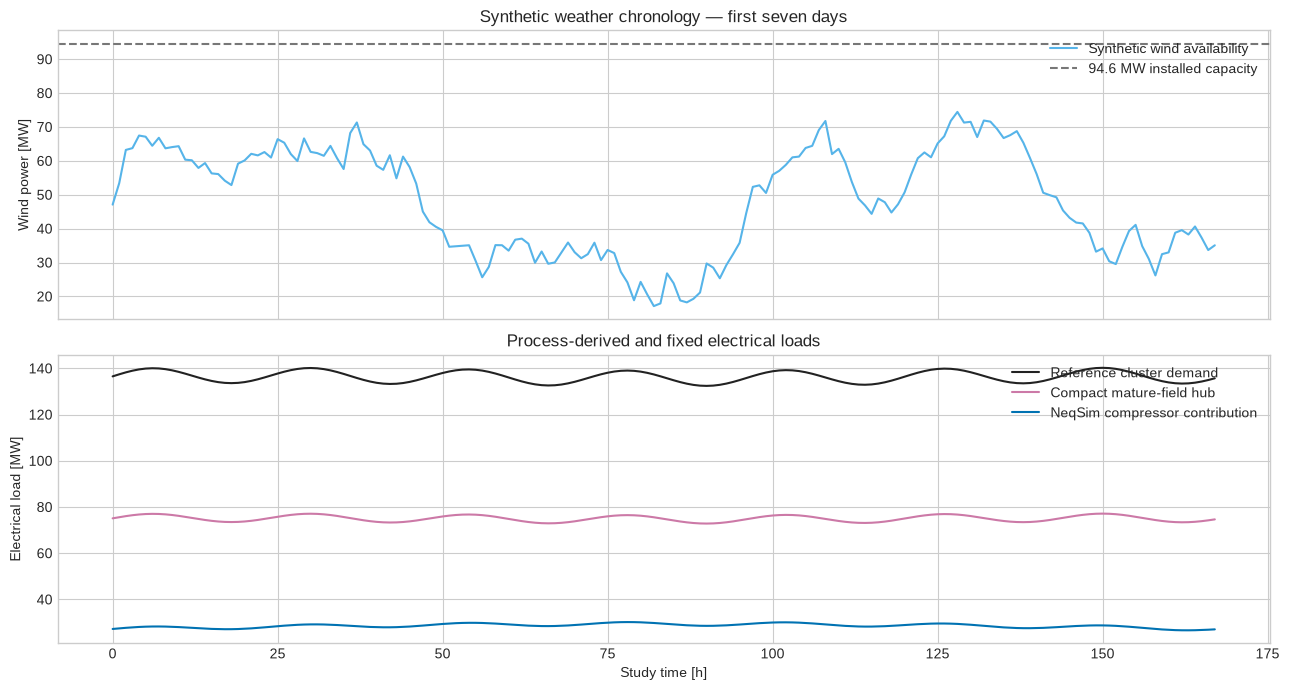

In [8]:
figure, axes = plt.subplots(2, 1, figsize=(13.0, 7.0), sharex=True)
display_hours = 7 * 24

axes[0].plot(
    hours[:display_hours],
    wind_available_mw[:display_hours],
    color=COLOR_WIND,
    label="Synthetic wind availability",
)
axes[0].axhline(
    HYWIND_CAPACITY_MW,
    color="#777777",
    linestyle="--",
    label="94.6 MW installed capacity",
)
axes[0].set_ylabel("Wind power [MW]")
axes[0].set_title("Synthetic weather chronology — first seven days")
axes[0].legend(loc="upper right")

axes[1].plot(
    hours[:display_hours],
    reference_demand_mw[:display_hours],
    color=COLOR_LOAD,
    label="Reference cluster demand",
)
axes[1].plot(
    hours[:display_hours],
    compact_demand_mw[:display_hours],
    color="#CC79A7",
    label="Compact mature-field hub",
)
axes[1].plot(
    hours[:display_hours],
    compressor_power_mw[:display_hours],
    color="#0072B2",
    label="NeqSim compressor contribution",
)
axes[1].set_xlabel("Study time [h]")
axes[1].set_ylabel("Electrical load [MW]")
axes[1].set_title("Process-derived and fixed electrical loads")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

The wind trace contains autocorrelation, shorter fluctuations, and a deliberate
low-wind spell. It is suitable for teaching chronological integration but not for
production forecasting, fatigue design, or an investment decision.

## 5. Native NeqSim time-series dispatch: gas only versus wind plus gas

Each producer and consumer is a typed electrical `EnergyPort` connected to one
`EnergyBus`. Wind has the first generation priority, gas turbines are the balancing
source, and the process load has the highest demand priority. The gas port carries
the benchmark cost and CO₂ factors, so only accepted gas generation accumulates
emissions.

In [9]:
times_seconds = JArray(JDouble)((hours * 3600.0).tolist())


def java_double_array(values):
    return JArray(JDouble)(np.asarray(values, dtype=float).tolist())


wind_profile = EnergyTimeSeriesProfile.step(
    "synthetic offshore wind",
    times_seconds,
    java_double_array(wind_available_mw * 1.0e6),
)
reference_load_profile = EnergyTimeSeriesProfile.step(
    "reference cluster electrical demand",
    times_seconds,
    java_double_array(reference_demand_mw * 1.0e6),
)
compact_load_profile = EnergyTimeSeriesProfile.step(
    "compact hub electrical demand",
    times_seconds,
    java_double_array(compact_demand_mw * 1.0e6),
)


def make_port(owner, direction, mode, bus, priority):
    port = EnergyPort(
        "power",
        EnergyType.ELECTRICAL,
        direction,
        mode,
    )
    port.setOwnerName(owner)
    port.setPriority(priority)
    port.connect(bus)
    return port


def allocation_map(report):
    return {
        str(allocation.getParticipantName()): allocation
        for allocation in report.getAllocations()
    }


def run_native_time_series(
    scenario_name,
    wind_values_mw,
    demand_values_mw,
):
    bus = EnergyBus(
        f"{scenario_name} electrical bus",
        EnergyType.ELECTRICAL,
    )
    wind = make_port(
        "offshore wind",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        0,
    )
    gas = make_port(
        "gas-turbine fleet",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        10,
    )
    process_load = make_port(
        "oil-and-gas process",
        EnergyPortDirection.INPUT,
        EnergyPortMode.SPECIFICATION,
        bus,
        0,
    )
    gas.setEnergyPricePerMWh(GT_COST_PER_MWH)
    gas.setEmissionFactorKgPerMWh(GT_CO2_KG_PER_MWH)

    simulator = EnergyTimeSeriesSimulator(
        ProcessSystem(f"{scenario_name} process")
    )
    simulator.addEnergyBus(bus)
    simulator.setIntervalSeconds(TIME_STEP_H * 3600.0)
    simulator.setDurationSeconds(STUDY_HOURS * 3600.0)

    scenario_wind_profile = EnergyTimeSeriesProfile.step(
        f"{scenario_name} wind",
        times_seconds,
        java_double_array(wind_values_mw * 1.0e6),
    )
    scenario_load_profile = EnergyTimeSeriesProfile.step(
        f"{scenario_name} load",
        times_seconds,
        java_double_array(demand_values_mw * 1.0e6),
    )
    gas_profile = EnergyTimeSeriesProfile.step(
        f"{scenario_name} firm gas capacity",
        times_seconds,
        java_double_array(
            np.full(STUDY_HOURS, GT_FIRM_CAPACITY_MW * 1.0e6)
        ),
    )

    targets = [
        JProxy(
            ProfileTarget,
            dict(apply=lambda value: wind.setDuty(float(value))),
        ),
        JProxy(
            ProfileTarget,
            dict(apply=lambda value: gas.setDuty(float(value))),
        ),
        JProxy(
            ProfileTarget,
            dict(
                apply=lambda value: process_load.setRequestedPower(
                    float(value)
                )
            ),
        ),
    ]
    simulator.addProfile(scenario_wind_profile, targets[0])
    simulator.addProfile(gas_profile, targets[1])
    simulator.addProfile(scenario_load_profile, targets[2])
    result = simulator.run()

    rows = []
    for interval in result.getIntervals():
        report = interval.getNetworkReports().get(0)
        allocations = allocation_map(report)
        wind_allocation = allocations["offshore wind.power"]
        gas_allocation = allocations["gas-turbine fleet.power"]
        rows.append(
            {
                "hour": (
                    interval.getStartTimeSeconds() / 3600.0
                ),
                "demand_mw": report.getServedDemand() / 1.0e6,
                "wind_mw": (
                    wind_allocation.getAllocatedPower() / 1.0e6
                ),
                "wind_curtailed_mw": (
                    wind_allocation.getCurtailedPower() / 1.0e6
                ),
                "gas_mw": (
                    gas_allocation.getAllocatedPower() / 1.0e6
                ),
                "unmet_mw": report.getUnmetDemand() / 1.0e6,
                "co2_kg_h": report.getCo2EmissionRate(),
            }
        )
    return result, pd.DataFrame(rows), targets


gas_only_result, gas_only_dispatch, gas_only_targets = (
    run_native_time_series(
        "gas only",
        np.zeros(STUDY_HOURS),
        reference_demand_mw,
    )
)
wind_gas_result, wind_gas_dispatch, wind_gas_targets = (
    run_native_time_series(
        "wind plus gas",
        wind_available_mw,
        reference_demand_mw,
    )
)

In [10]:
def dispatch_metrics(dispatch, demand_values_mw):
    gas_energy_mwh = dispatch["gas_mw"].sum() * TIME_STEP_H
    wind_energy_mwh = dispatch["wind_mw"].sum() * TIME_STEP_H
    available_wind_mwh = (
        (
            dispatch["wind_mw"]
            + dispatch["wind_curtailed_mw"]
        ).sum()
        * TIME_STEP_H
    )
    process_energy_mwh = demand_values_mw.sum() * TIME_STEP_H
    co2_tonnes = (
        gas_energy_mwh * GT_CO2_KG_PER_MWH / 1000.0
    )
    return {
        "Process energy [MWh]": process_energy_mwh,
        "Accepted wind [MWh]": wind_energy_mwh,
        "Gas generation [MWh]": gas_energy_mwh,
        "Wind curtailment [MWh]": max(
            0.0,
            available_wind_mwh - wind_energy_mwh,
        ),
        "Unmet energy [MWh]": (
            dispatch["unmet_mw"].sum() * TIME_STEP_H
        ),
        "Direct CO₂ [t]": co2_tonnes,
        "Peak gas [MW]": dispatch["gas_mw"].max(),
        "P95 gas ramp [MW/h]": np.percentile(
            np.abs(np.diff(dispatch["gas_mw"])),
            95.0,
        ),
    }


native_comparison = pd.DataFrame(
    [
        {
            "Scenario": "Gas turbines only",
            **dispatch_metrics(
                gas_only_dispatch,
                reference_demand_mw,
            ),
        },
        {
            "Scenario": "Wind + balancing gas turbines",
            **dispatch_metrics(
                wind_gas_dispatch,
                reference_demand_mw,
            ),
        },
    ]
)
display(native_comparison.round(3))

,Scenario,Process energy [MWh],Accepted wind [MWh],Gas generation [MWh],Wind curtailment [MWh],Unmet energy [MWh],Direct CO₂ [t],Peak gas [MW],P95 gas ramp [MW/h]
0,Gas turbines only,97302.857,0.0,97302.857,0.0,0.0,43786.286,140.236,0.886
1,Wind + balancing gas turbines,97302.857,34056.0,63246.857,0.0,0.0,28461.086,132.297,7.175


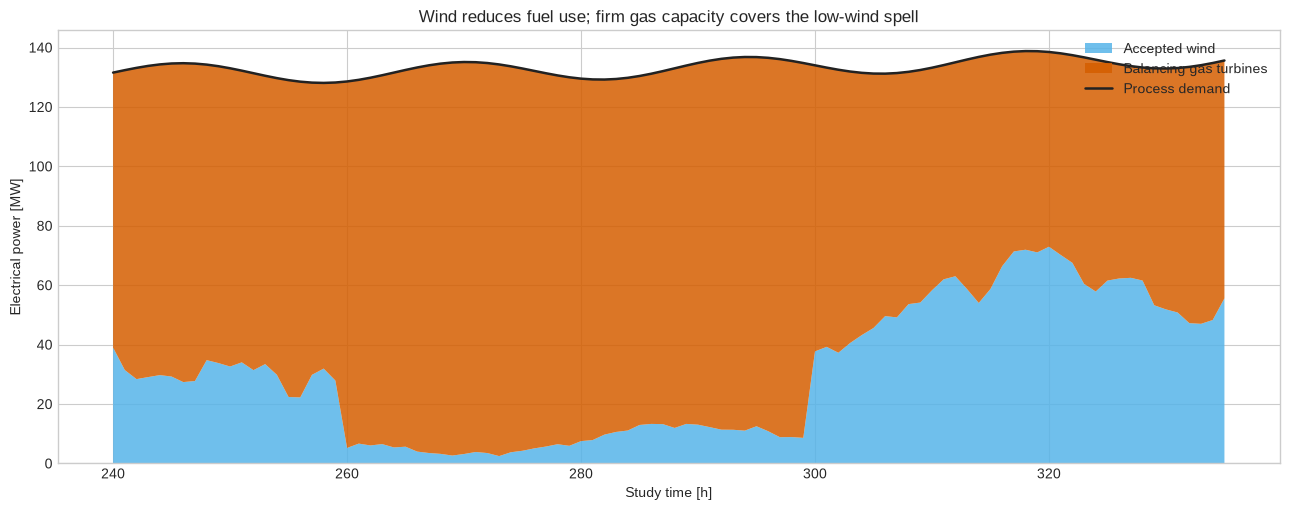

In [11]:
dispatch_window = slice(240, 336)
dispatch_hours = hours[dispatch_window]

figure, axis = plt.subplots(figsize=(13.0, 5.2))
axis.stackplot(
    dispatch_hours,
    wind_gas_dispatch.iloc[dispatch_window]["wind_mw"],
    wind_gas_dispatch.iloc[dispatch_window]["gas_mw"],
    labels=["Accepted wind", "Balancing gas turbines"],
    colors=[COLOR_WIND, COLOR_GAS],
    alpha=0.85,
)
axis.plot(
    dispatch_hours,
    reference_demand_mw[dispatch_window],
    color=COLOR_LOAD,
    linewidth=1.8,
    label="Process demand",
)
axis.set_xlabel("Study time [h]")
axis.set_ylabel("Electrical power [MW]")
axis.set_title(
    "Wind reduces fuel use; firm gas capacity covers the low-wind spell"
)
axis.legend(loc="upper right")
plt.tight_layout()
plt.show()

Direct offshore emissions are integrated from accepted gas generation:

$$
m_\mathrm{CO_2}
=
\sum_i
P_{\mathrm{GT},i}
\Delta t_i
EF_\mathrm{GT}
$$

Wind reduces the gas-energy integral, but installed gas capacity remains necessary
because the synthetic chronology includes hours with little wind.

## 6. Native battery storage and an explicit dispatch policy

The battery is a NeqSim `BatteryStorage` unit connected to the same electrical
`EnergyBus`. The control policy is intentionally visible:

- charge only from wind that would otherwise be surplus;
- discharge into a wind deficit before gas generation;
- respect charge power, discharge power, state-of-charge, and efficiency limits;
- start empty, so the battery receives no unreported initial low-carbon energy.

This greedy controller is auditable but not globally optimal. Project work may add
weather forecasts, start avoidance, spinning reserve, degradation, or mixed-integer
scheduling.

With stored energy $E$, charge efficiency $\eta_c$, discharge efficiency
$\eta_d$, and one-hour step $\Delta t$, NeqSim applies:

$$
E_{i+1}
=
E_i
+
\eta_c P_{c,i}\Delta t
-
\frac{P_{d,i}\Delta t}{\eta_d}
$$

The study uses $\eta_c=\eta_d=0.95$, giving 90.25% electrical round-trip
efficiency before auxiliary loads or degradation.

In [12]:
BATTERY_CHARGE_EFFICIENCY = 0.95
BATTERY_DISCHARGE_EFFICIENCY = 0.95


def run_battery_dispatch(
    scenario_name,
    demand_values_mw,
    battery_capacity_mwh,
    battery_power_mw,
):
    bus = EnergyBus(
        f"{scenario_name} electrical bus",
        EnergyType.ELECTRICAL,
    )
    wind = make_port(
        "offshore wind",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        0,
    )
    gas = make_port(
        "gas-turbine fleet",
        EnergyPortDirection.OUTPUT,
        EnergyPortMode.CALCULATED,
        bus,
        10,
    )
    process_load = make_port(
        "oil-and-gas process",
        EnergyPortDirection.INPUT,
        EnergyPortMode.SPECIFICATION,
        bus,
        0,
    )
    gas.setEmissionFactorKgPerMWh(GT_CO2_KG_PER_MWH)
    gas.setEnergyPricePerMWh(GT_COST_PER_MWH)

    battery = None
    if battery_capacity_mwh > 0.0:
        battery = BatteryStorage(
            "battery",
            battery_capacity_mwh * 1.0e6,
        )
        battery.setStateOfCharge(0.0)
        battery.setEfficiencies(
            BATTERY_CHARGE_EFFICIENCY,
            BATTERY_DISCHARGE_EFFICIENCY,
        )
        battery.setPowerLimits(
            battery_power_mw * 1.0e6,
            battery_power_mw * 1.0e6,
        )
        battery.connectEnergyStream(
            BatteryStorage.ELECTRICAL_PORT,
            bus,
            EnergyPortMode.CALCULATED,
        )
        battery.getEnergyPort(
            BatteryStorage.ELECTRICAL_PORT
        ).setPriority(5)

    rows = []
    for hour_index in range(STUDY_HOURS):
        time_seconds = float(hour_index * 3600.0)
        available_wind_mw = (
            wind_profile.getValue(time_seconds) / 1.0e6
        )
        demand_mw = float(demand_values_mw[hour_index])
        battery_power_requested_mw = 0.0
        battery_power_actual_mw = 0.0

        if battery is not None:
            surplus_mw = max(
                available_wind_mw - demand_mw,
                0.0,
            )
            deficit_mw = max(
                demand_mw - available_wind_mw,
                0.0,
            )
            if surplus_mw > 0.0:
                headroom_mwh = (
                    battery.getCapacity()
                    - battery.getStateOfCharge()
                ) / 1.0e6
                headroom_power_mw = (
                    headroom_mwh
                    / (
                        BATTERY_CHARGE_EFFICIENCY
                        * TIME_STEP_H
                    )
                )
                charge_mw = min(
                    surplus_mw,
                    battery_power_mw,
                    headroom_power_mw,
                )
                battery.charge(
                    charge_mw * 1.0e6,
                    TIME_STEP_H,
                )
            elif deficit_mw > 0.0:
                battery.discharge(
                    min(deficit_mw, battery_power_mw)
                    * 1.0e6,
                    TIME_STEP_H,
                )
            else:
                battery.charge(0.0, TIME_STEP_H)
            battery.run(UUID.randomUUID())
            battery_power_requested_mw = (
                battery.getCurrentPower() / 1.0e6
            )

        wind.setDuty(available_wind_mw * 1.0e6)
        gas.setDuty(GT_FIRM_CAPACITY_MW * 1.0e6)
        process_load.setRequestedPower(demand_mw * 1.0e6)
        report = bus.solveBalance()
        allocations = allocation_map(report)
        wind_allocation = allocations["offshore wind.power"]
        gas_allocation = allocations["gas-turbine fleet.power"]
        if battery is not None:
            battery_allocation_mw = (
                allocations["battery.electricalPower"]
                .getAllocatedPower()
                / 1.0e6
            )
            if abs(battery_power_requested_mw) > 1.0e-12:
                battery_power_actual_mw = math.copysign(
                    battery_allocation_mw,
                    battery_power_requested_mw,
                )

        rows.append(
            {
                "hour": float(hour_index),
                "demand_mw": demand_mw,
                "wind_available_mw": available_wind_mw,
                "wind_mw": (
                    wind_allocation.getAllocatedPower() / 1.0e6
                ),
                "wind_curtailed_mw": (
                    wind_allocation.getCurtailedPower() / 1.0e6
                ),
                "gas_mw": (
                    gas_allocation.getAllocatedPower() / 1.0e6
                ),
                "battery_requested_mw": (
                    battery_power_requested_mw
                ),
                "battery_mw": battery_power_actual_mw,
                "soc_mwh": (
                    0.0
                    if battery is None
                    else battery.getStateOfCharge() / 1.0e6
                ),
                "unmet_mw": report.getUnmetDemand() / 1.0e6,
                "co2_kg_h": report.getCo2EmissionRate(),
            }
        )

    dispatch = pd.DataFrame(rows)
    metrics = dispatch_metrics(dispatch, demand_values_mw)
    metrics.update(
        {
            "Battery capacity [MWh]": battery_capacity_mwh,
            "Battery power [MW]": battery_power_mw,
            "Battery charge [MWh]": (
                -dispatch["battery_mw"].clip(upper=0.0).sum()
                * TIME_STEP_H
            ),
            "Battery discharge [MWh]": (
                dispatch["battery_mw"].clip(lower=0.0).sum()
                * TIME_STEP_H
            ),
            "Final SOC [MWh]": dispatch["soc_mwh"].iloc[-1],
        }
    )
    return dispatch, metrics

In [13]:
reference_no_battery, reference_no_battery_metrics = (
    run_battery_dispatch(
        "reference wind and gas",
        reference_demand_mw,
        battery_capacity_mwh=0.0,
        battery_power_mw=0.0,
    )
)
reference_battery, reference_battery_metrics = (
    run_battery_dispatch(
        "reference wind battery and gas",
        reference_demand_mw,
        battery_capacity_mwh=100.0,
        battery_power_mw=50.0,
    )
)
compact_no_battery, compact_no_battery_metrics = (
    run_battery_dispatch(
        "compact wind and gas",
        compact_demand_mw,
        battery_capacity_mwh=0.0,
        battery_power_mw=0.0,
    )
)
compact_battery, compact_battery_metrics = (
    run_battery_dispatch(
        "compact wind battery and gas",
        compact_demand_mw,
        battery_capacity_mwh=100.0,
        battery_power_mw=50.0,
    )
)

battery_case_table = pd.DataFrame(
    [
        {
            "Load archetype": "Reference cluster",
            "Scenario": "Wind + GT",
            **reference_no_battery_metrics,
        },
        {
            "Load archetype": "Reference cluster",
            "Scenario": "Wind + 100 MWh battery + GT",
            **reference_battery_metrics,
        },
        {
            "Load archetype": "Compact mature hub",
            "Scenario": "Wind + GT",
            **compact_no_battery_metrics,
        },
        {
            "Load archetype": "Compact mature hub",
            "Scenario": "Wind + 100 MWh battery + GT",
            **compact_battery_metrics,
        },
    ]
)
display(
    battery_case_table[
        [
            "Load archetype",
            "Scenario",
            "Accepted wind [MWh]",
            "Gas generation [MWh]",
            "Wind curtailment [MWh]",
            "Battery charge [MWh]",
            "Battery discharge [MWh]",
            "Direct CO₂ [t]",
            "Peak gas [MW]",
            "P95 gas ramp [MW/h]",
        ]
    ].round(3)
)

,Load archetype,Scenario,Accepted wind [MWh],Gas generation [MWh],Wind curtailment [MWh],Battery charge [MWh],Battery discharge [MWh],Direct CO₂ [t],Peak gas [MW],P95 gas ramp [MW/h]
0,Reference cluster,Wind + GT,34056.000,63246.857,0.000,-0.000,0.000,28461.086,132.297,7.175
1,Reference cluster,Wind + 100 MWh battery + GT,34056.000,63246.857,0.000,-0.000,0.000,28461.086,132.297,7.175
2,Compact mature hub,Wind + GT,33757.748,19758.823,298.252,-0.000,0.000,8891.470,71.567,7.103
3,Compact mature hub,Wind + 100 MWh battery + GT,34016.177,19525.591,39.823,258.429,233.232,8786.516,71.567,7.214


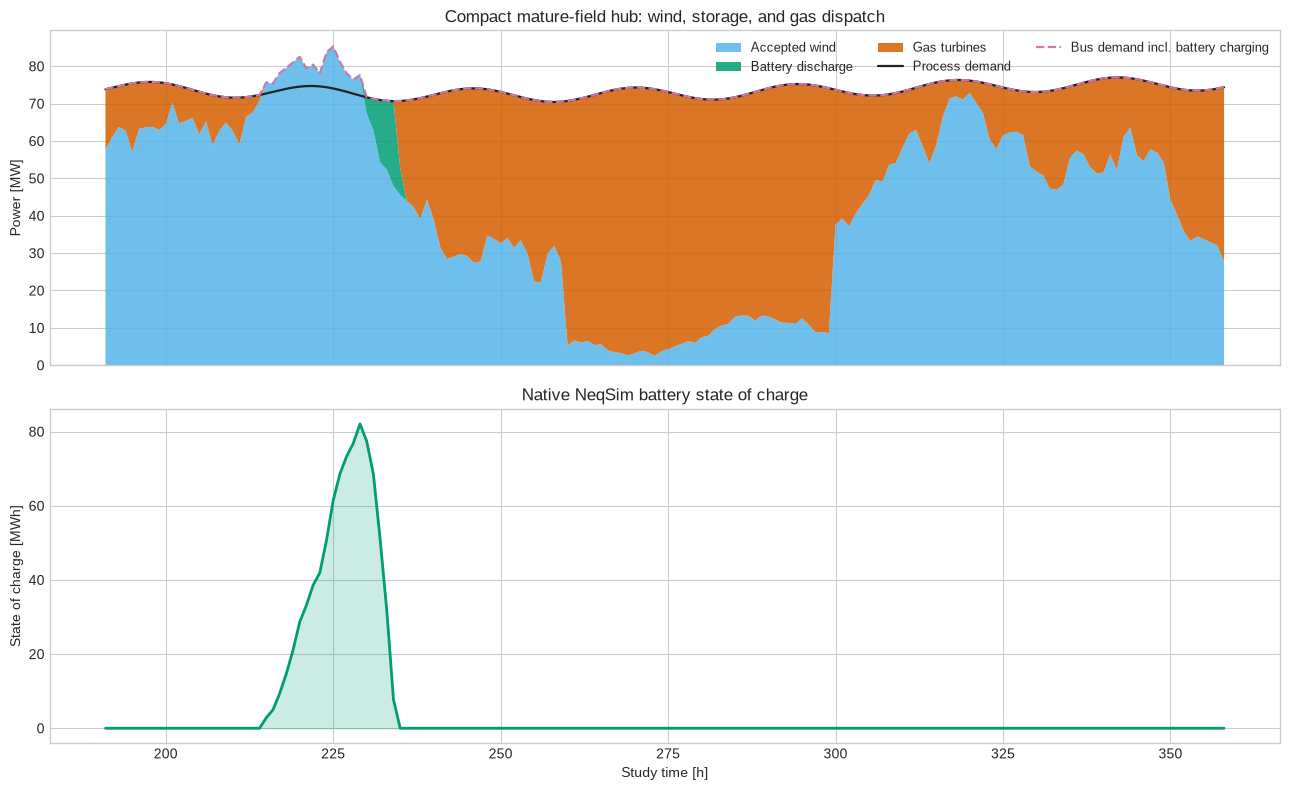

In [14]:
active_soc_indices = np.flatnonzero(
    compact_battery["soc_mwh"].to_numpy() > 1.0e-6
)
assert len(active_soc_indices) > 0
display_start = max(0, int(active_soc_indices[0]) - 24)
display_stop = min(STUDY_HOURS, display_start + 168)
display_window = slice(display_start, display_stop)
display_time = hours[display_window]
figure, axes = plt.subplots(2, 1, figsize=(13.0, 8.0), sharex=True)

axes[0].stackplot(
    display_time,
    compact_battery.iloc[display_window]["wind_mw"],
    compact_battery.iloc[display_window][
        "battery_mw"
    ].clip(lower=0.0),
    compact_battery.iloc[display_window]["gas_mw"],
    labels=["Accepted wind", "Battery discharge", "Gas turbines"],
    colors=[COLOR_WIND, COLOR_BATTERY, COLOR_GAS],
    alpha=0.85,
)
axes[0].plot(
    display_time,
    compact_demand_mw[display_window],
    color=COLOR_LOAD,
    linewidth=1.6,
    label="Process demand",
)
bus_demand_mw = (
    compact_demand_mw[display_window]
    - compact_battery.iloc[display_window][
        "battery_mw"
    ].clip(upper=0.0)
)
axes[0].plot(
    display_time,
    bus_demand_mw,
    color="#CC79A7",
    linestyle="--",
    linewidth=1.6,
    label="Bus demand incl. battery charging",
)
axes[0].set_ylabel("Power [MW]")
axes[0].set_title(
    "Compact mature-field hub: wind, storage, and gas dispatch"
)
axes[0].legend(loc="upper right", ncol=3, fontsize=9)

axes[1].plot(
    display_time,
    compact_battery.iloc[display_window]["soc_mwh"],
    color=COLOR_BATTERY,
    linewidth=2.0,
)
axes[1].fill_between(
    display_time,
    0.0,
    compact_battery.iloc[display_window]["soc_mwh"],
    color=COLOR_BATTERY,
    alpha=0.20,
)
axes[1].set_xlabel("Study time [h]")
axes[1].set_ylabel("State of charge [MWh]")
axes[1].set_title("Native NeqSim battery state of charge")

plt.tight_layout()
plt.show()

In the reference cluster, instantaneous demand is always above the 94.6 MW wind
maximum, so almost no wind is curtailed and an energy-shifting battery has little
additional CO₂ value under this policy. In the compact hub, high-wind hours exceed
demand; storage captures part of that surplus and displaces later gas generation.
This is why storage value increases as fields mature or renewable capacity is
oversized relative to load.

## 7. Why a battery alone is not an emissions source

A battery shifts energy; it does not create low-carbon energy. If it is charged only
from gas turbines and gas-turbine CO₂ intensity is constant, losses increase total
fuel use. A detailed plant may still benefit from fewer starts, better turbine load,
reserve support, or avoided flaring, but those mechanisms must be modelled rather
than assumed.

In [15]:
battery_efficiency_check = BatteryStorage(
    "round-trip check",
    20.0e6,
)
battery_efficiency_check.setEfficiencies(
    BATTERY_CHARGE_EFFICIENCY,
    BATTERY_DISCHARGE_EFFICIENCY,
)
battery_efficiency_check.setPowerLimits(20.0e6, 20.0e6)
battery_efficiency_check.charge(10.0e6, 1.0)
delivered_power_w = battery_efficiency_check.discharge(
    10.0e6,
    1.0,
)

electrical_round_trip_efficiency = (
    delivered_power_w / 10.0e6
)
shifted_fraction = 0.10
reference_process_energy_mwh = (
    reference_demand_mw.sum() * TIME_STEP_H
)
shifted_delivered_mwh = (
    shifted_fraction * reference_process_energy_mwh
)
battery_only_extra_gas_mwh = shifted_delivered_mwh * (
    1.0 / electrical_round_trip_efficiency - 1.0
)
battery_only_extra_co2_t = (
    battery_only_extra_gas_mwh
    * GT_CO2_KG_PER_MWH
    / 1000.0
)

battery_only_check = pd.Series(
    {
        "Charged energy [MWh]": 10.0,
        "Delivered energy [MWh]": delivered_power_w / 1.0e6,
        "Electrical round-trip efficiency [%]": (
            100.0 * electrical_round_trip_efficiency
        ),
        "Illustrative energy shifted [%]": (
            100.0 * shifted_fraction
        ),
        "Extra gas generation [MWh/30 d]": (
            battery_only_extra_gas_mwh
        ),
        "Extra direct CO₂ [t/30 d]": battery_only_extra_co2_t,
    }
)
display(battery_only_check.to_frame("Value").round(3))

,Value
Charged energy [MWh],10.000
Delivered energy [MWh],9.025
Electrical round-trip efficiency [%],90.250
Illustrative energy shifted [%],10.000
Extra gas generation [MWh/30 d],1051.194
Extra direct CO₂ [t/30 d],473.037


## 8. Battery-size and field-maturity sensitivity

The following grid repeats the native bus and battery calculation for five demand
levels and four energy capacities. Battery power is limited to the smaller of
50 MW and half the energy capacity per hour. Each cell reports extra CO₂ reduction
relative to wind plus gas without storage at the same demand level.

In [16]:
demand_scales = [0.45, 0.55, 0.75, 1.00, 1.25]
battery_capacities_mwh = [0.0, 50.0, 100.0, 200.0]
sensitivity_rows = []

for demand_scale in demand_scales:
    scaled_demand_mw = demand_scale * reference_demand_mw
    base_dispatch, base_metrics = run_battery_dispatch(
        f"base scale {demand_scale}",
        scaled_demand_mw,
        battery_capacity_mwh=0.0,
        battery_power_mw=0.0,
    )
    for capacity_mwh in battery_capacities_mwh:
        if capacity_mwh == 0.0:
            metrics = base_metrics
        else:
            _, metrics = run_battery_dispatch(
                f"battery scale {demand_scale} cap {capacity_mwh}",
                scaled_demand_mw,
                battery_capacity_mwh=capacity_mwh,
                battery_power_mw=min(
                    50.0,
                    0.5 * capacity_mwh,
                ),
            )
        additional_reduction_t = (
            base_metrics["Direct CO₂ [t]"]
            - metrics["Direct CO₂ [t]"]
        )
        additional_reduction_percent = (
            100.0
            * additional_reduction_t
            / base_metrics["Direct CO₂ [t]"]
            if base_metrics["Direct CO₂ [t]"] > 0.0
            else 0.0
        )
        sensitivity_rows.append(
            {
                "Demand scale": demand_scale,
                "Battery [MWh]": capacity_mwh,
                "Extra CO₂ reduction [%]": (
                    additional_reduction_percent
                ),
                "Wind curtailed [MWh]": (
                    metrics["Wind curtailment [MWh]"]
                ),
                "P95 gas ramp [MW/h]": (
                    metrics["P95 gas ramp [MW/h]"]
                ),
            }
        )

battery_sensitivity = pd.DataFrame(sensitivity_rows)
reduction_pivot = battery_sensitivity.pivot(
    index="Demand scale",
    columns="Battery [MWh]",
    values="Extra CO₂ reduction [%]",
)
display(reduction_pivot.round(3))

Battery [MWh],0.0,50.0,100.0,200.0
Demand scale,,,,
0.45,0.0,3.857,6.001,8.965
0.55,0.0,0.756,1.180,1.362
0.75,0.0,0.000,0.000,0.000
1.00,0.0,0.000,0.000,0.000
1.25,0.0,0.000,0.000,0.000


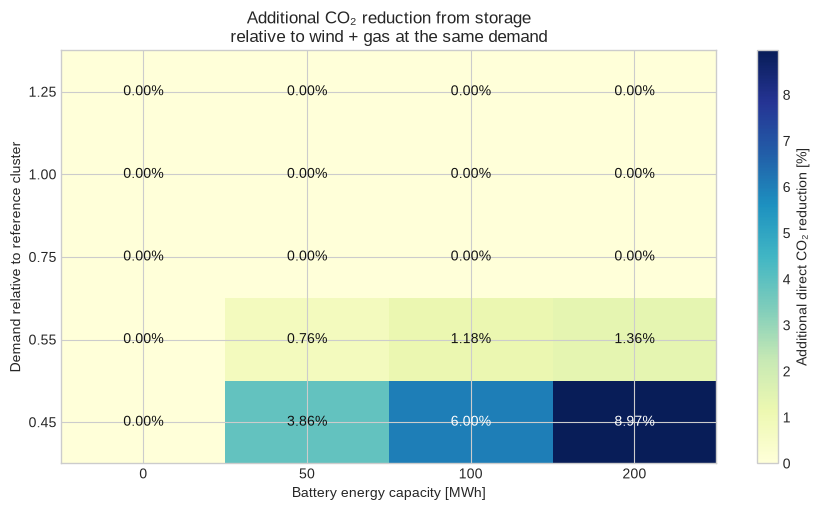

In [17]:
figure, axis = plt.subplots(figsize=(9.0, 5.2))
image = axis.imshow(
    reduction_pivot.values,
    aspect="auto",
    cmap="YlGnBu",
    origin="lower",
)
axis.set_xticks(np.arange(len(reduction_pivot.columns)))
axis.set_xticklabels(
    [f"{value:.0f}" for value in reduction_pivot.columns]
)
axis.set_yticks(np.arange(len(reduction_pivot.index)))
axis.set_yticklabels(
    [f"{value:.2f}" for value in reduction_pivot.index]
)
axis.set_xlabel("Battery energy capacity [MWh]")
axis.set_ylabel("Demand relative to reference cluster")
axis.set_title(
    "Additional CO₂ reduction from storage\n"
    "relative to wind + gas at the same demand"
)

for row_index in range(reduction_pivot.shape[0]):
    for column_index in range(reduction_pivot.shape[1]):
        value = reduction_pivot.iloc[
            row_index,
            column_index,
        ]
        text_color = (
            "white"
            if value
            > 0.55 * reduction_pivot.to_numpy().max()
            else "#111111"
        )
        axis.text(
            column_index,
            row_index,
            f"{value:.2f}%",
            ha="center",
            va="center",
            color=text_color,
        )

colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("Additional direct CO₂ reduction [%]")
plt.tight_layout()
plt.show()

Storage provides the most emissions value where wind curtailment exists. Once the
available surplus is captured, adding more MWh produces diminishing returns.
At high demand, storage may still improve ramps, ride-through, starts, or reserve,
but energy-only CO₂ savings approach zero.

## 9. Firm gas-turbine capacity and operational screening

Wind and batteries reduce fuel use but are not treated as firm capacity in this
deterministic screen. The example fleet has six 35 MW gas-turbine generators. One
unit is reserved for an N+1 outage, leaving 175 MW firm gas capacity. A 15% spinning
reserve margin is applied to the instantaneous gas requirement.

This is a capacity and ramp screen only. AC load flow, fault level, voltage and
frequency stability, black start, protection, cable limits, and platform
distribution are outside the notebook.

In [18]:
GT_UNIT_CAPACITY_MW = 35.0
GT_INSTALLED_UNITS = 6
GT_N_PLUS_ONE_FIRM_MW = (
    (GT_INSTALLED_UNITS - 1) * GT_UNIT_CAPACITY_MW
)
SPINNING_RESERVE_FRACTION = 0.15


def firming_metrics(dispatch):
    gas_requirement_mw = dispatch["gas_mw"].to_numpy()
    reserve_requirement_mw = (
        gas_requirement_mw
        * (1.0 + SPINNING_RESERVE_FRACTION)
    )
    return {
        "Peak gas duty [MW]": gas_requirement_mw.max(),
        "Peak incl. 15% reserve [MW]": (
            reserve_requirement_mw.max()
        ),
        "N+1 firm capacity [MW]": GT_N_PLUS_ONE_FIRM_MW,
        "Hours above N+1 capacity": int(
            np.sum(
                reserve_requirement_mw
                > GT_N_PLUS_ONE_FIRM_MW
            )
        ),
        "P95 ramp [MW/h]": np.percentile(
            np.abs(np.diff(gas_requirement_mw)),
            95.0,
        ),
        "Maximum ramp [MW/h]": np.max(
            np.abs(np.diff(gas_requirement_mw))
        ),
    }


firming_table = pd.DataFrame(
    [
        {
            "Scenario": "Reference gas only",
            **firming_metrics(gas_only_dispatch),
        },
        {
            "Scenario": "Reference wind + gas",
            **firming_metrics(reference_no_battery),
        },
        {
            "Scenario": "Reference wind + battery + gas",
            **firming_metrics(reference_battery),
        },
        {
            "Scenario": "Compact wind + gas",
            **firming_metrics(compact_no_battery),
        },
        {
            "Scenario": "Compact wind + battery + gas",
            **firming_metrics(compact_battery),
        },
    ]
)
display(firming_table.round(3))

,Scenario,Peak gas duty [MW],Peak incl. 15% reserve [MW],N+1 firm capacity [MW],Hours above N+1 capacity,P95 ramp [MW/h],Maximum ramp [MW/h]
0,Reference gas only,140.236,161.271,175.0,0,0.886,0.945
1,Reference wind + gas,132.297,152.142,175.0,0,7.175,29.884
2,Reference wind + battery + gas,132.297,152.142,175.0,0,7.175,29.884
3,Compact wind + gas,71.567,82.302,175.0,0,7.103,29.536
4,Compact wind + battery + gas,71.567,82.302,175.0,0,7.214,29.536


Gas turbines remain installed even when their annual energy falls substantially.
This separates two decisions that are often conflated:

- **energy displacement:** fewer gas-turbine MWh and lower direct CO₂; and
- **capacity replacement:** less installed firm generation.

The first can be large with wind. The second requires a reliability study and may
remain close to zero for an islanded offshore system.

## 10. Annualised option comparison

The 30-day chronology is annualised only to make the order of magnitude readable:

$$
X_\mathrm{annual}
=
X_\mathrm{30d}
\frac{8760}{720}
$$

This repeats the synthetic month; it does not replace a full-year measured or
hindcast wind series.

In [19]:
annualisation_factor = 8760.0 / STUDY_HOURS


def annual_row(load_archetype, scenario, metrics, baseline_co2_t):
    annual_co2_kt = (
        metrics["Direct CO₂ [t]"]
        * annualisation_factor
        / 1000.0
    )
    reduction_percent = (
        100.0
        * (baseline_co2_t - metrics["Direct CO₂ [t]"])
        / baseline_co2_t
    )
    available_wind_mwh = (
        wind_available_mw.sum() * TIME_STEP_H
    )
    return {
        "Load archetype": load_archetype,
        "Scenario": scenario,
        "Process energy [GWh/y]": (
            metrics["Process energy [MWh]"]
            * annualisation_factor
            / 1000.0
        ),
        "Accepted wind [GWh/y]": (
            metrics["Accepted wind [MWh]"]
            * annualisation_factor
            / 1000.0
        ),
        "Gas generation [GWh/y]": (
            metrics["Gas generation [MWh]"]
            * annualisation_factor
            / 1000.0
        ),
        "Direct CO₂ [kt/y]": annual_co2_kt,
        "CO₂ reduction vs GT only [%]": reduction_percent,
        "Wind utilised [%]": (
            100.0
            * metrics["Accepted wind [MWh]"]
            / available_wind_mwh
        ),
        "Peak gas [MW]": metrics["Peak gas [MW]"],
        "P95 gas ramp [MW/h]": (
            metrics["P95 gas ramp [MW/h]"]
        ),
    }


reference_gas_metrics = dispatch_metrics(
    gas_only_dispatch,
    reference_demand_mw,
)
compact_gas_dispatch, compact_gas_metrics = run_battery_dispatch(
    "compact gas only",
    compact_demand_mw,
    battery_capacity_mwh=0.0,
    battery_power_mw=0.0,
)
compact_gas_metrics["Accepted wind [MWh]"] = 0.0
compact_gas_metrics["Gas generation [MWh]"] = (
    compact_demand_mw.sum() * TIME_STEP_H
)
compact_gas_metrics["Direct CO₂ [t]"] = (
    compact_gas_metrics["Gas generation [MWh]"]
    * GT_CO2_KG_PER_MWH
    / 1000.0
)
compact_gas_metrics["Peak gas [MW]"] = compact_demand_mw.max()
compact_gas_metrics["P95 gas ramp [MW/h]"] = np.percentile(
    np.abs(np.diff(compact_demand_mw)),
    95.0,
)

annual_options = pd.DataFrame(
    [
        annual_row(
            "Reference cluster",
            "Gas turbines only",
            reference_gas_metrics,
            reference_gas_metrics["Direct CO₂ [t]"],
        ),
        annual_row(
            "Reference cluster",
            "Wind + gas turbines",
            reference_no_battery_metrics,
            reference_gas_metrics["Direct CO₂ [t]"],
        ),
        annual_row(
            "Reference cluster",
            "Wind + 100 MWh battery + gas",
            reference_battery_metrics,
            reference_gas_metrics["Direct CO₂ [t]"],
        ),
        annual_row(
            "Compact mature hub",
            "Gas turbines only",
            compact_gas_metrics,
            compact_gas_metrics["Direct CO₂ [t]"],
        ),
        annual_row(
            "Compact mature hub",
            "Wind + gas turbines",
            compact_no_battery_metrics,
            compact_gas_metrics["Direct CO₂ [t]"],
        ),
        annual_row(
            "Compact mature hub",
            "Wind + 100 MWh battery + gas",
            compact_battery_metrics,
            compact_gas_metrics["Direct CO₂ [t]"],
        ),
    ]
)
display(annual_options.round(3))

,Load archetype,Scenario,Process energy [GWh/y],Accepted wind [GWh/y],Gas generation [GWh/y],Direct CO₂ [kt/y],CO₂ reduction vs GT only [%],Wind utilised [%],Peak gas [MW],P95 gas ramp [MW/h]
0,Reference cluster,Gas turbines only,1183.851,0.000,1183.851,532.733,0.000,0.000,140.236,0.886
1,Reference cluster,Wind + gas turbines,1183.851,414.348,769.503,346.277,35.000,100.000,132.297,7.175
2,Reference cluster,Wind + 100 MWh battery + gas,1183.851,414.348,769.503,346.277,35.000,100.000,132.297,7.175
3,Compact mature hub,Gas turbines only,651.118,0.000,651.118,293.003,0.000,0.000,77.130,0.487
4,Compact mature hub,Wind + gas turbines,651.118,410.719,240.399,108.180,63.079,99.124,71.567,7.103
5,Compact mature hub,Wind + 100 MWh battery + gas,651.118,413.863,237.561,106.903,63.515,99.883,71.567,7.214


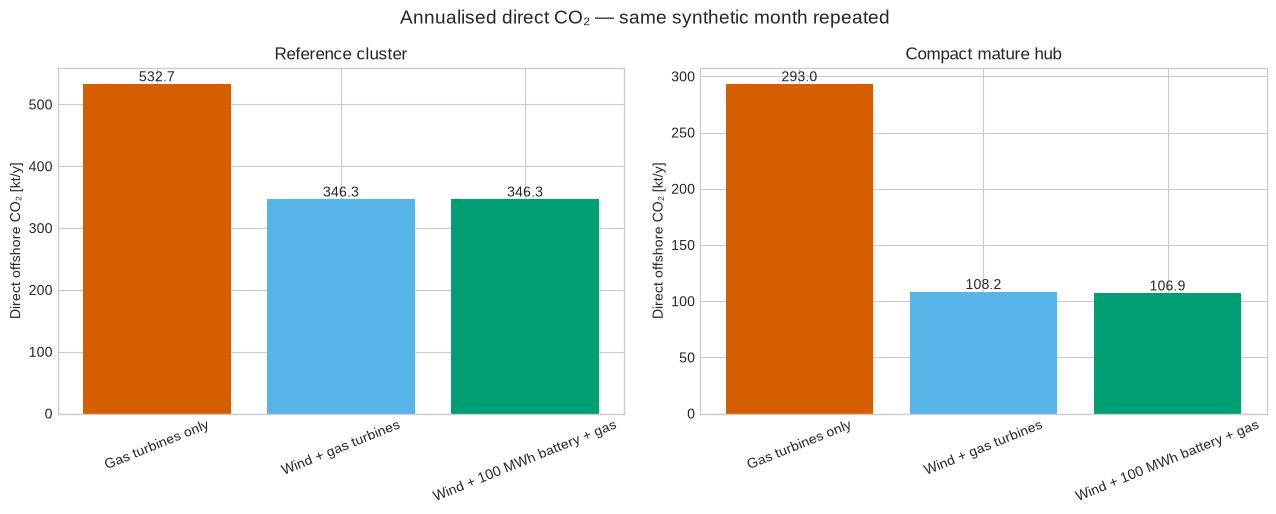

In [20]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))

for axis, archetype in zip(
    axes,
    ["Reference cluster", "Compact mature hub"],
):
    subset = annual_options[
        annual_options["Load archetype"] == archetype
    ]
    bars = axis.bar(
        subset["Scenario"],
        subset["Direct CO₂ [kt/y]"],
        color=[COLOR_GAS, COLOR_WIND, COLOR_BATTERY],
    )
    axis.set_title(archetype)
    axis.set_ylabel("Direct offshore CO₂ [kt/y]")
    axis.tick_params(axis="x", rotation=22)
    for bar, value in zip(
        bars,
        subset["Direct CO₂ [kt/y]"],
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            value,
            f"{value:.1f}",
            ha="center",
            va="bottom",
        )

figure.suptitle(
    "Annualised direct CO₂ — same synthetic month repeated",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## 11. Decision interpretation for Norwegian Continental Shelf studies

**Existing high-load platform cluster.** A Hywind-scale wind farm can displace a
large share of gas-turbine energy while almost all wind is consumed directly.
An energy-shifting battery adds little CO₂ reduction if there is no curtailment, but
may still support ramping, frequency response, spinning reserve, starts, and
ride-through.

**Late-life or smaller hub.** As process demand declines, wind surplus grows.
Storage can capture otherwise curtailed wind and produce additional CO₂ reduction,
with diminishing returns as energy capacity increases.

**Battery with gas turbines only.** Under a constant gas-turbine emission factor,
storage losses increase fuel use. Any claimed benefit must come from explicitly
modelled part-load efficiency, start avoidance, operating reserve, or another
mechanism.

**Power from shore.** Grid connection can reduce direct offshore emissions and may
replace more local energy generation, but a fair comparison requires cable and
transformer losses, onshore generation or marginal intensity, grid constraints,
availability, reserve philosophy, and lifecycle boundaries. Those project-specific
inputs are intentionally not invented here.

**Do not remove balancing turbines from this result.** The notebook shows annual
energy displacement, not a conclusion that firm gas capacity can be retired.

## 12. Validation gates

The final checks cover source provenance, the repository benchmark, process
material and energy closure, monotonic compressor behaviour, profile calibration,
chronological balances, storage state, emissions trends, and firm-capacity
screening.

In [21]:
validation_checks = {
    "Pinned NeqSim commit loaded": resolved_commit == NEQSIM_COMMIT,
    "Benchmark served energy": math.isclose(
        benchmark_result.getServedEnergyMWh(),
        312.0,
        abs_tol=1.0e-9,
    ),
    "Benchmark has no unmet energy": math.isclose(
        benchmark_result.getUnmetEnergyMWh(),
        0.0,
        abs_tol=1.0e-9,
    ),
    "Benchmark accepted wind": math.isclose(
        OffshoreEnergyReferenceCase.getWindGeneratedEnergyMWh(
            benchmark_result
        ),
        144.0,
        abs_tol=1.0e-9,
    ),
    "Benchmark accepted gas": math.isclose(
        OffshoreEnergyReferenceCase.getGasGeneratedEnergyMWh(
            benchmark_result
        ),
        168.0,
        abs_tol=1.0e-9,
    ),
    "Benchmark emissions": math.isclose(
        benchmark_result.getCo2EmissionsKg(),
        75_600.0,
        abs_tol=1.0e-6,
    ),
    "Gas composition normalized": math.isclose(
        sum(gas_composition.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "Compressor mass closure": (
        compressor_cases["Mass residual [kg/h]"].abs().max()
        < 1.0e-6
    ),
    "Compressor energy closure": (
        compressor_cases["Energy residual [W]"].abs().max()
        < 1.0e-4
    ),
    "Compressor power increases with flow": bool(
        np.all(np.diff(compressor_cases["Power [MW]"]) > 0.0)
    ),
    "Compressor discharge hotter than inlet": bool(
        np.all(
            compressor_cases["Outlet temperature [°C]"] > 25.0
        )
    ),
    "Synthetic wind capacity factor calibrated": math.isclose(
        wind_capacity_factor.mean(),
        TARGET_WIND_CAPACITY_FACTOR,
        abs_tol=1.0e-10,
    ),
    "Reference annual wind-share target calibrated": math.isclose(
        wind_available_mw.mean()
        / reference_demand_mw.mean(),
        TARGET_REFERENCE_WIND_SHARE,
        abs_tol=1.0e-10,
    ),
    "Gas-only native simulation serves load": (
        gas_only_dispatch["unmet_mw"].abs().max() < 1.0e-9
    ),
    "Wind-plus-gas native simulation serves load": (
        wind_gas_dispatch["unmet_mw"].abs().max() < 1.0e-9
    ),
    "Native wind-plus-gas power balance": (
        np.max(
            np.abs(
                wind_gas_dispatch["wind_mw"]
                + wind_gas_dispatch["gas_mw"]
                - wind_gas_dispatch["demand_mw"]
            )
        )
        < 1.0e-9
    ),
    "Wind reduces direct CO₂": (
        reference_no_battery_metrics["Direct CO₂ [t]"]
        < reference_gas_metrics["Direct CO₂ [t]"]
    ),
    "Reference battery stays within capacity": (
        reference_battery["soc_mwh"].between(0.0, 100.0).all()
    ),
    "Compact battery stays within capacity": (
        compact_battery["soc_mwh"].between(0.0, 100.0).all()
    ),
    "Compact battery has no unmet load": (
        compact_battery["unmet_mw"].abs().max() < 1.0e-9
    ),
    "Compact battery captures wind": (
        compact_battery_metrics["Accepted wind [MWh]"]
        > compact_no_battery_metrics["Accepted wind [MWh]"]
    ),
    "Compact battery reduces gas generation": (
        compact_battery_metrics["Gas generation [MWh]"]
        < compact_no_battery_metrics["Gas generation [MWh]"]
    ),
    "Battery bus allocation matches request": (
        (
            compact_battery["battery_mw"]
            - compact_battery["battery_requested_mw"]
        ).abs().max()
        < 1.0e-9
    ),
    "Native battery round-trip efficiency": math.isclose(
        electrical_round_trip_efficiency,
        0.95 * 0.95,
        rel_tol=1.0e-12,
    ),
    "Battery-only gas charging increases CO₂": (
        battery_only_extra_co2_t > 0.0
    ),
    "N+1 screen passes reference wind case": (
        firming_metrics(reference_no_battery)[
            "Hours above N+1 capacity"
        ]
        == 0
    ),
}

failed_checks = [
    name
    for name, passed in validation_checks.items()
    if not passed
]
validation_table = pd.DataFrame(
    [
        {"Validation check": name, "Passed": bool(passed)}
        for name, passed in validation_checks.items()
    ]
)
display(validation_table)
assert not failed_checks, f"Failed validation checks: {failed_checks}"
print(
    f"All {len(validation_checks)} engineering validation checks passed."
)

,Validation check,Passed
0,Pinned NeqSim commit loaded,True
1,Benchmark served energy,True
2,Benchmark has no unmet energy,True
3,Benchmark accepted wind,True
4,Benchmark accepted gas,True
5,Benchmark emissions,True
6,Gas composition normalized,True
7,Compressor mass closure,True
8,Compressor energy closure,True
9,Compressor power increases with flow,True


All 26 engineering validation checks passed.


## Limitations

- The wind trace is synthetic and only 30 days long.
- The process is a compact export-compressor model plus explicit fixed loads.
- The gas-turbine CO₂ factor is constant; load, ambient temperature, degradation,
  starts, fuel composition, methane slip, and NOₓ are not varied.
- The battery controller is greedy; degradation, availability, thermal limits,
  converter losses, reserve markets, and optimal scheduling are excluded.
- The study is an electrical energy balance, not AC load flow, transient frequency
  stability, cable design, protection coordination, or safety certification.
- Direct offshore CO₂ is not the same boundary as lifecycle greenhouse-gas impact.
- Costs are benchmark units only. CAPEX, OPEX, gas value, taxes, support schemes,
  carbon prices, and decommissioning are project-specific.

## Suggested extensions

1. Replace the synthetic wind profile with an authorised measured or hindcast year.
2. Couple several NeqSim compressors, pumps, water-injection trains, and heaters.
3. Use `CommittedEnergyGenerator` for multiple turbine units, starts, minimum load,
   ramp rates, and minimum up/down time.
4. Optimise battery power and energy capacity against curtailment, starts, CO₂, and
   lifecycle cost.
5. Add a power-from-shore port with explicit grid intensity, losses, availability,
   and boundary definitions.
6. Run production-decline cases to quantify how storage value changes through field
   life.

## References

- [Equinor: Hywind Tampen](https://www.equinor.com/energy/hywind-tampen)
- [NeqSim: energy time-series simulation](https://equinor.github.io/neqsim/process/energy_time_series.html)
- [NeqSim: energy streams and equipment ports](https://equinor.github.io/neqsim/process/energy_streams.html)
- [NeqSim: offshore energy reference case](https://equinor.github.io/neqsim/process/offshore_energy_reference_case.html)
- [Pinned NeqSim source commit](https://github.com/equinor/neqsim/commit/77f4b5b1d225372947a69864b47940fe0f86430a)